# Notebook (#?): Evaluation
Evaluates BM25 retrieval on the 1906 Chronicling America corpus using manually labeled relevance judgments.

Qrels are stored in `../data/qrels.json`, edit that file to update labels, not this notebook.

In [17]:
import os
import json
import pandas as pd
import pyterrier as pt
import matplotlib.pyplot as plt

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home"
os.environ["JVM_PATH"]  = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home/lib/server/libjvm.dylib"

if not pt.started():
    pt.init()

print("PyTerrier", pt.__version__)

PyTerrier 1.0.2


/var/folders/sj/z4b7r7m16t93q2qp3qwcwdwr0000gn/T/ipykernel_18019/2740789145.py:10: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


## 1. Load corpus & index

In [18]:
df = pd.read_parquet("../data/corpus.parquet")
print(f"Corpus: {len(df)} docs")
df.head(2)

Corpus: 608 docs


,doc_id,lccn,date,edition,page,raw_text,clean_text,token_count
0,sn83035387_1906_01_06_ed1_seq1,sn83035387,1906-01-06,1,1,TIIE G AZETTE\nTWENTY-THIRD YEAR. NO. 23.\nThe...,tiie azett twenti third year fashion uay autho...,3239
1,sn83035387_1906_01_06_ed1_seq2,sn83035387,1906-01-06,1,2,2\nTHE GAZETTE.\nPUBLISHED EVERY SATURDAY.\nSU...,gazett publish everi saturday subscript rate a...,3700


In [19]:
INDEX_PATH = "../data/pt_index"
index = pt.IndexFactory.of(INDEX_PATH)
print(index.getCollectionStatistics().toString())

Number of documents: 608
Number of terms: 54172
Number of postings: 688989
Number of fields: 0
Number of tokens: 1234007
Field names: []
Positions:   false



## 2. Queries

In [20]:
queries = pd.DataFrame([
    {"qid": "1",  "query": "earthquake fire san francisco"},
    {"qid": "2",  "query": "railroad strike labor"},
    {"qid": "3",  "query": "election president congress"},
    {"qid": "4",  "query": "war military troops"},
    {"qid": "5",  "query": "weather storm flood"},
    {"qid": "6",  "query": "crime murder trial"},
    {"qid": "7",  "query": "business market prices"},
    {"qid": "8",  "query": "church sunday religion"},
    {"qid": "9",  "query": "school education children"},
    {"qid": "10", "query": "disease death hospital"},
])
queries

,qid,query
0,1,earthquake fire san francisco
1,2,railroad strike labor
2,3,election president congress
3,4,war military troops
4,5,weather storm flood
5,6,crime murder trial
6,7,business market prices
7,8,church sunday religion
8,9,school education children
9,10,disease death hospital


## 3. Retrieve with BM25

In [21]:
bm25 = pt.terrier.Retriever(index, wmodel="BM25", num_results=20)
results = bm25.transform(queries)
print(f"Retrieved {len(results)} rows across {results['qid'].nunique()} queries")
results.head()

Retrieved 200 rows across 10 queries


,qid,docid,docno,rank,score,query
0,1,63,sn83035387_1906_04_21_ed1_seq4,0,14.774044,earthquake fire san francisco
1,1,347,sn84020235_1906_05_05_ed1_seq2,1,14.522445,earthquake fire san francisco
2,1,65,sn83035387_1906_04_28_ed1_seq2,2,14.116376,earthquake fire san francisco
3,1,351,sn84020235_1906_05_05_ed1_seq6,3,13.527361,earthquake fire san francisco
4,1,373,sn84020235_1906_05_26_ed1_seq4,4,13.508947,earthquake fire san francisco


## 3b. Inspect results
Use `show_results(qid)` to browse retrieved docs for any query — useful for labeling or sanity checking other retrieval methods.

In [ ]:
QUERY_LABELS = {
    "1":  "earthquake fire san francisco",
    "2":  "railroad strike labor",
    "3":  "election president congress",
    "4":  "war military troops",
    "5":  "weather storm flood",
    "6":  "crime murder trial",
    "7":  "business market prices",
    "8":  "church sunday religion",
    "9":  "school education children",
    "10": "disease death hospital",
}

def show_results(qid, result_df=None, top_n=20, text_len=600):
    """Print ranked results for a query with snippet text.
    
    Args:
        qid:       query id string, e.g. '1'
        result_df: results DataFrame (defaults to BM25 results)
        top_n:     how many results to show
        text_len:  characters of raw text to display per doc
    """
    if result_df is None:
        result_df = results
    subset = result_df[result_df["qid"] == str(qid)].head(top_n).reset_index(drop=True)
    print(f"Query {qid}: '{QUERY_LABELS.get(str(qid), '?')}' — {len(subset)} results")
    print("=" * 80)
    for _, row in subset.iterrows():
        doc_rows = df[df["doc_id"] == row["docno"]]
        if doc_rows.empty:
            print(f"rank {int(row['rank'])+1:>2} | {row['docno']} | [NOT FOUND IN CORPUS]")
            continue
        doc = doc_rows.iloc[0]
        date = str(doc.get("date", ""))[:10]
        score = f"{row['score']:.4f}" if "score" in row else ""
        print(f"rank {int(row['rank'])+1:>2} | score {score} | {row['docno']} | {date}")
        snippet = str(doc.get("raw_text", ""))[:text_len].replace("\n", " ")
        print(snippet)
        print("-" * 80)

# change qid to inspect any query
show_results("6")

Query 6: 'crime murder trial' — 20 results
rank  1 | score 7.2923 | sn83035387_1906_10_13_ed1_seq1 | 1906-10-13
THE W GAZETTE TWENTY-FOURT BUCKEYE HAPPENINGS FROM MANY BUCKEYE CITIES AND TOWNS—SENT BY OUR OWN CORRESPONDENTS. • PERSONAL. SOCIAL, LODGE, CHURCH, LITERARY AND OTHER NOTES OF IN TEREST. Behefontaine.—Mrs. Scott, of South- Rend, Ind., is visiting her sister, Mrs. Bray. Mrs. Scott* Mrs. Bray and daughter visited in Mechanicsburg.— Rev. Dorsey was in Pickreltown Sun day.—Mrs. Laura Glaspy gave a re ception Thursday in honor of Mrs. Bertha Kinslin and Miss Roberta Stewart. —Mrs. Laura Clark has re turned from Cincinnati and Spring field.—-Grace church concert. Tuesday night was fine.—The Second B
--------------------------------------------------------------------------------
rank  2 | score 7.1446 | sn83035387_1906_12_15_ed1_seq1 | 1906-12-15
THE GAZETTE ■ay* ~^~E- TWENTY-FOURTH YEAR. NO. 20. THEY HURT. Some of the President’s Statements in His RECENT MESSAGE They Are Wrong—See

## 4. Load relevance judgments

Labels live in `../data/qrels.json`. Format:
```json
{
  "1": {
    "sn84020235_1906_05_05_ed1_seq6": 1,
    "sn83035387_1906_04_21_ed1_seq4": 0,
    ...
  },
  ...
}
```
Only docs with label=1 are included in qrels (non-relevant docs are implicitly 0 in PyTerrier).

In [23]:
with open("../data/qrels.json") as f:
    qrels_raw = json.load(f)

# Only keep relevant docs (label=1); PyTerrier treats unlabeled as non-relevant
rows = []
for qid, docs in qrels_raw.items():
    for docno, label in docs.items():
        if label == 1:
            rows.append({"qid": qid, "docno": docno, "label": 1})

qrels = pd.DataFrame(rows)
print(f"qrels: {len(qrels_raw) * 20} judgments across {len(qrels_raw)} queries")
print(f"Relevant docs: {len(qrels)}")
qrels.head()

qrels: 200 judgments across 10 queries
Relevant docs: 11


,qid,docno,label
0,1,sn84020235_1906_05_05_ed1_seq6,1
1,2,sn84020235_1906_06_09_ed1_seq2,1
2,6,sn83035387_1906_12_15_ed1_seq1,1
3,6,sn83035387_1906_06_30_ed1_seq1,1
4,6,sn83035387_1906_07_28_ed1_seq1,1


## 5. Evaluate

In [24]:
eval_results = pt.Experiment(
    [results],
    queries,
    qrels,
    eval_metrics=["P_5", "P_10", "recall_5", "ndcg_cut_5"],
    names=["BM25"],
    perquery=False
)
eval_results

,name,P_5,P_10,recall_5,ndcg_cut_5
0,BM25,0.166667,0.116667,0.347222,0.259772


## 6. Per-query breakdown

In [25]:
per_query = pt.Experiment(
    [results],
    queries,
    qrels,
    eval_metrics=["P_5", "P_10", "recall_5", "ndcg_cut_5"],
    names=["BM25"],
    perquery=True
)
per_query

/opt/anaconda3/lib/python3.12/site-packages/pyterrier/_evaluation/_execution.py:47: UserWarning: 4 topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.
  warn(f'{backfill_count} topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.')


,name,qid,measure,value
0,BM25,1,P_5,0.200000
1,BM25,1,P_10,0.100000
2,BM25,1,recall_5,1.000000
3,BM25,1,ndcg_cut_5,0.430677
36,BM25,10,P_5,NaN
37,BM25,10,P_10,NaN
38,BM25,10,recall_5,NaN
39,BM25,10,ndcg_cut_5,NaN
4,BM25,2,P_5,0.000000
5,BM25,2,P_10,0.100000


## 7. Visualization

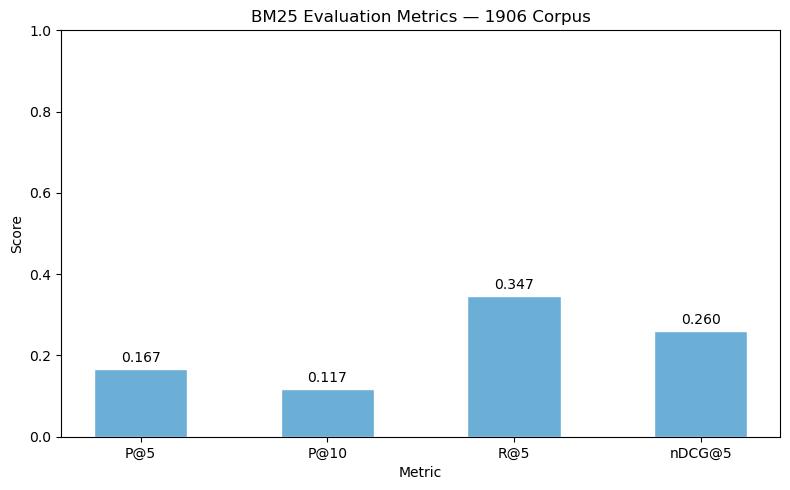

In [26]:
metrics = ["P_5", "P_10", "recall_5", "ndcg_cut_5"]
labels  = ["P@5", "P@10", "R@5", "nDCG@5"]
scores  = [eval_results[m].iloc[0] for m in metrics]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color="#6baed6", edgecolor="white", width=0.5)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("BM25 Evaluation Metrics — 1906 Corpus")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("../data/bm25_eval.png", dpi=150)
plt.show()

## 8. Discussion

BM25 achieved P@5 = 0.167, P@10 = 0.117, R@5 = 0.347, and nDCG@5 = 0.260. Four queries (election, war, weather, disease) returned NaN because no relevant documents appeared in those results at all. Q7 (business) was the strongest result with P@5 = 0.60 and nDCG@5 = 0.83. P@5 > P@10 shows relevant docs tend to rank near the top, meaning BM25 is working.

The low scores come down to two things. First, documents are full newspaper pages, not individual articles. Every page mixes ads, mastheads, and unrelated content, so query terms match incidentally rather than topically. Second, both newspapers are Black community press (Cleveland Gazette, St. Louis Palladium), which focus on community news and civil rights rather than weather, military, or electoral coverage.

Segmenting pages into individual articles before indexing would likely improve results the most. Expanding beyond 608 pages would help coverage for the topics that returned nothing.